In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

# Credit Risk Dashboard – German Credit Data

Provide a risk dashboard for a binary credit risk model
(PD = Probability of Default), using the German credit dataset.


In [3]:
df = pd.read_csv("german_credit_data.csv")

# Change the Risk Column into binary (0 = good, 1 = bad)
df['Risk_binary'] = df['Risk'].map({'good': 0, 'bad': 1})
df = df.drop(['Risk','Unnamed: 0'], axis=1)

X = df.drop(columns=['Risk_binary'])
y = df['Risk_binary']

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numeric features: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical features: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [4]:
# Define the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), #standardizing -> numeric_features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) #onehotencoding -> categorical_features
    ]
)

# Logistic regression as baseline PD model
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the model
clf.fit(X_train, y_train)

# Predict probabilities (PD = P(y=1 = bad))
y_pred_proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC (test set): {auc:.3f}")

AUC (test set): 0.761


## 1. Portfolio Overview

Basic distribution of good vs. bad customers in the test set.

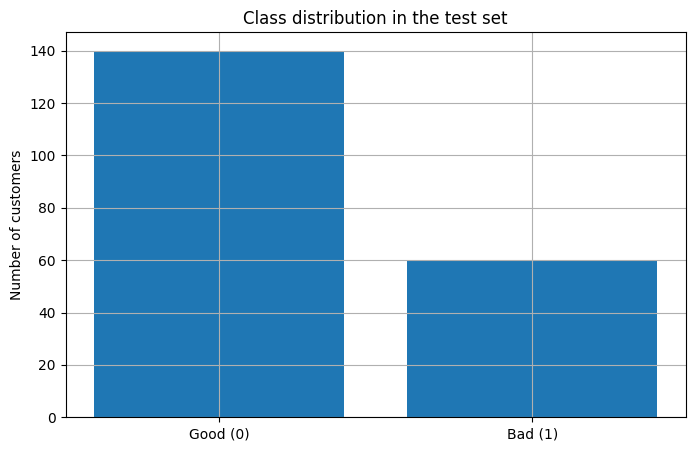

Risk_binary
0    140
1     60
Name: count, dtype: int64

In [5]:
# Class distribution in the test set
class_counts = y_test.value_counts().sort_index()
labels = ['Good (0)', 'Bad (1)']

plt.bar(labels, class_counts.values)
plt.title("Class distribution in the test set")
plt.ylabel("Number of customers")
plt.show()

class_counts

## 2. Model Performance

Evaluate the model using ROC/AUC, confusion matrix and classification report.

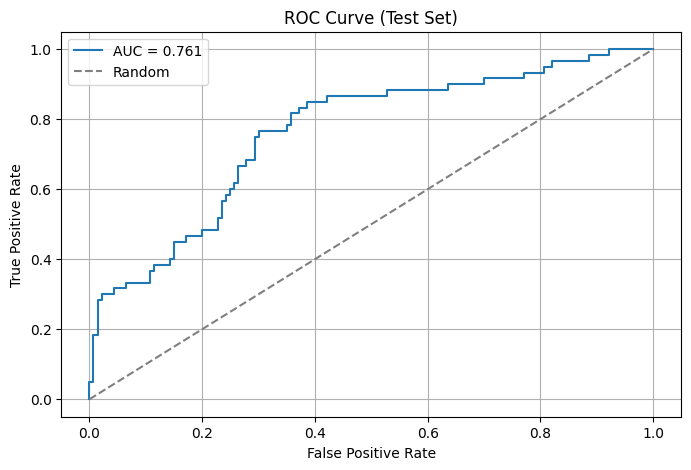

In [6]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

Confusion matrix:


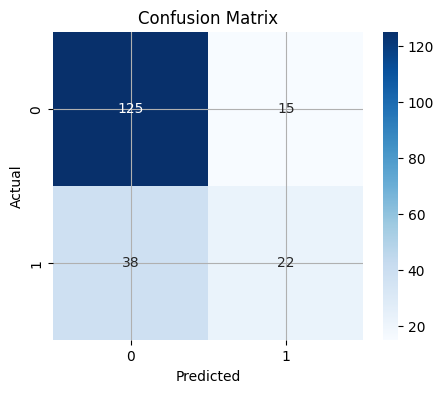


Classification report:
              precision    recall  f1-score   support

           0      0.767     0.893     0.825       140
           1      0.595     0.367     0.454        60

    accuracy                          0.735       200
   macro avg      0.681     0.630     0.639       200
weighted avg      0.715     0.735     0.714       200



In [7]:
# Confusion matrix & classification report
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

## 3. PD Segmentation (Bucketed Calibration)

Group observations into PD buckets and compare:
- average predicted PD
- observed default rate (bad rate)

→ check ranking and calibration of a credit risk model.

In [10]:
# Prepare evaluation dataframe
results = pd.DataFrame({
    'y_true': y_test.values,    #1 = bad (default), 0 = good
    'pd_hat': y_pred_proba      #predicted PD = P(bad)
})

# Create 5 PD buckets (0 = lowest risk, 4 = highest risk)
results['pd_bucket'] = pd.qcut(results['pd_hat'], q=5, labels=False)

# Aggregate statistics per PD bucket
pd_segment = results.groupby('pd_bucket').agg(
    n_obs=('y_true', 'size'),
    avg_pd=('pd_hat', 'mean'),
    default_rate=('y_true', 'mean')  # mean of 1/0 = observed default rate
).reset_index()

pd_segment

,pd_bucket,n_obs,avg_pd,default_rate
0,0,40,0.072772,0.125
1,1,40,0.149070,0.075
2,2,40,0.250852,0.275
3,3,40,0.412666,0.450
4,4,40,0.622647,0.575


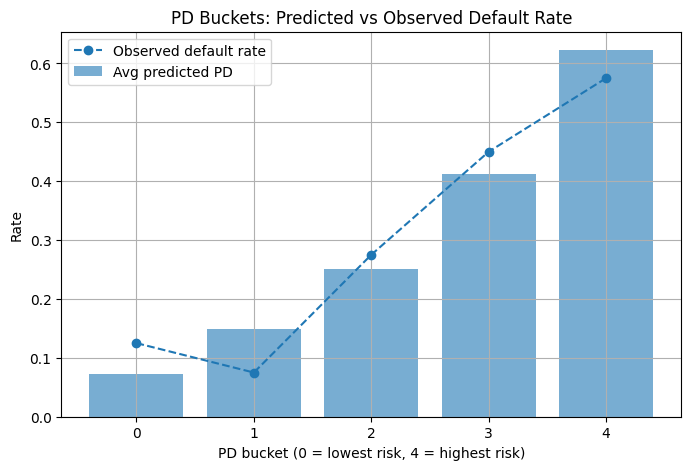

In [11]:
# Plot average predicted PD vs observed default rate per bucket
x = pd_segment['pd_bucket'].astype(str)

plt.bar(x, pd_segment['avg_pd'], alpha=0.6, label='Avg predicted PD')
plt.plot(x, pd_segment['default_rate'], marker='o', linestyle='--', label='Observed default rate')

plt.xlabel("PD bucket (0 = lowest risk, 4 = highest risk)")
plt.ylabel("Rate")
plt.title("PD Buckets: Predicted vs Observed Default Rate")
plt.legend()
plt.show()

## 4. Stability Check 


### 4.1 Train vs. Test PD Distribution

Simply compare the distribution of predicted PD between the training and test sets
to see if there is any obvious drift.

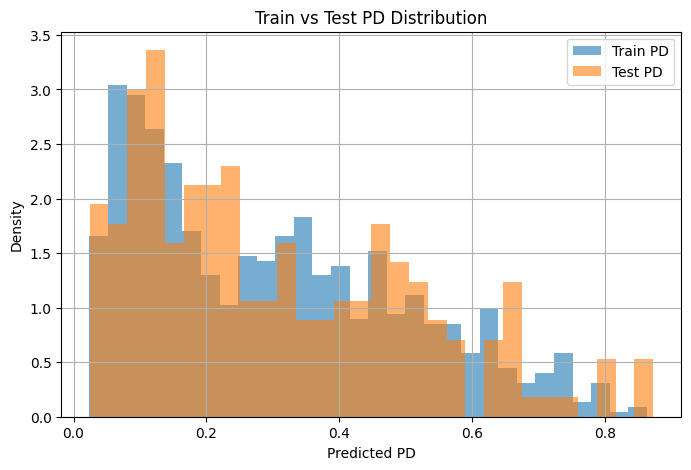

In [12]:
# Predicted PD on the training set
y_pred_proba_train = clf.predict_proba(X_train)[:, 1]

plt.hist(y_pred_proba_train, bins=30, alpha=0.6, density=True, label='Train PD')
plt.hist(y_pred_proba, bins=30, alpha=0.6, density=True, label='Test PD')
plt.xlabel("Predicted PD")
plt.ylabel("Density")
plt.title("Train vs Test PD Distribution")
plt.legend()
plt.show()

### 4.2 Population Stability Index (PSI)

Use the **Population Stability Index (PSI)** to measure the shift between:

- the **training set** (used to fit the model), and  
- the **test set** (out-of-sample),

for both the predicted PD distribution and selected input features.

>Typical interpretation (rule of thumb):
>
>- PSI < 0.10 → **no relevant shift**
>- 0.10 ≤ PSI < 0.25 → **moderate shift, monitor closely**
>- PSI ≥ 0.25 → **significant shift, potential model instability**


In [20]:
def calculate_psi(expected, actual, buckets=10):
    """
    Calculate the Population Stability Index (PSI) between two distributions:
    expected: array-like, reference distribution (e.g. train sample) 
    actual: array-like, comparison distribution (e.g. test sample)
    buckets: number of quantile-based bins
    """
    expected = np.array(expected)
    actual = np.array(actual)

    # Create bin edges using quantiles from the expected distribution
    quantiles = np.linspace(0, 1, buckets + 1)
    breakpoints = np.quantile(expected, quantiles)

    # Ensure bin edges are unique (avoid issues when values repeat)
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) - 1 < buckets: #reduce bins if needed
        buckets = len(breakpoints) - 1

    # Count how many observations fall into each bin
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _   = np.histogram(actual,   bins=breakpoints)

    # Change to proportions
    expected_perc = expected_counts / len(expected)
    actual_perc   = actual_counts  / len(actual)

    # Replace zeros to avoid division/log errors
    eps = 1e-6
    expected_perc = np.where(expected_perc == 0, eps, expected_perc)
    actual_perc   = np.where(actual_perc   == 0, eps, actual_perc)

    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)
    psi = np.sum(psi_values)

    return psi

In [21]:
# PSI for predicted PD distribution: train vs test
psi_pd = calculate_psi(y_pred_proba_train, y_pred_proba, buckets=10)
print(f"PSI for predicted PD (train vs test): {psi_pd:.4f}")

PSI for predicted PD (train vs test): 0.0678


In [16]:
# PSI for one example numeric feature, e.g. 'Credit amount'
if 'Credit amount' in X_train.columns:
    psi_credit_amount = calculate_psi(
        X_train['Credit amount'],
        X_test['Credit amount'],
        buckets=10
    )
    print(f"PSI for 'Credit amount' (train vs test): {psi_credit_amount:.4f}")
else:
    print("Feature 'Credit amount' not found in X_train.")

PSI for 'Credit amount' (train vs test): 0.0443


In [17]:
psi_summary = []

psi_summary.append({'metric': 'PD_score',        'psi': psi_pd})
psi_summary.append({'metric': 'Credit amount', 'psi': psi_credit_amount})
psi_df = pd.DataFrame(psi_summary)
psi_df

,metric,psi
0,PD_score,0.067756
1,Credit amount,0.044266


## 5. Simple Stress Test

Apply a scenario: Assume the economy gets worse, `Credit amount` increase by 20% for all customers in the test set
and measure the impact on the average PD.

In [22]:
# Baseline average PD on the test set
baseline_pd = results['pd_hat'].mean()
print(f"Baseline average PD (test set): {baseline_pd:.4f}")

# Stress scenario in the test set
X_test_stress = X_test.copy()
if 'Credit amount' in X_test_stress.columns:
    X_test_stress['Credit amount'] = X_test_stress['Credit amount'] * 1.2
else:
    print("Warning: 'Credit amount' column name may be different, please check!")

# Re-predict PDs under this stress scenario
y_pred_proba_stress = clf.predict_proba(X_test_stress)[:, 1]
stress_pd = y_pred_proba_stress.mean()

print(f"Stress scenario average PD (+20% credit amount): {stress_pd:.4f}")
print(f"ΔPD (stress - baseline): {stress_pd - baseline_pd:.4f}")

Baseline average PD (test set): 0.3016
Stress scenario average PD (+20% credit amount): 0.3030
ΔPD (stress - baseline): 0.0014


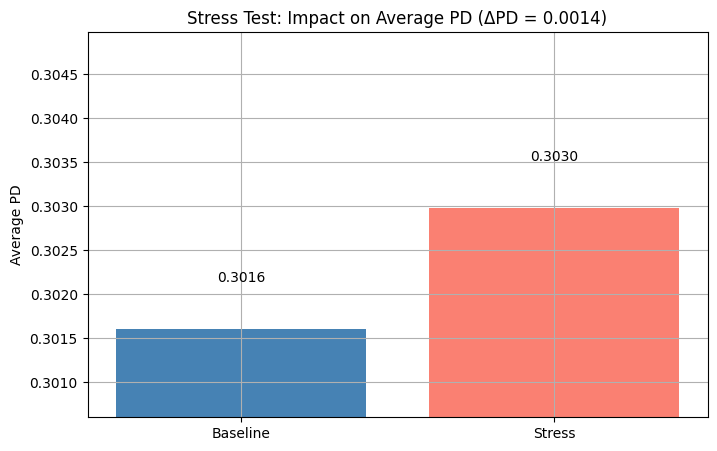

In [23]:
# Bar chart for baseline vs stress
labels = ['Baseline', 'Stress']
values = [baseline_pd, stress_pd]

plt.figure()
bars = plt.bar(labels, values, color=['steelblue', 'salmon'])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h + 0.0005,
             f"{h:.4f}",
             ha='center', va='bottom')

delta = stress_pd - baseline_pd

plt.ylabel("Average PD")
plt.title(f"Stress Test: Impact on Average PD (ΔPD = {delta:.4f})")
plt.ylim(min(values) - 0.001, max(values) + 0.002)
plt.show()

## 6. Summary

- **Model type:** Logistic regression with standardized numeric features and one-hot encoded categorical features.
- **Evaluation:** Test AUC ≈ *0.761* → reasonable separation between good and bad customers.
- **Calibration:** PD buckets show that higher PD bands have higher observed default rates. Predicted PDs are generally aligned with realized default rates.
- **Stability:** The PD distribution between training & test sets looks similar + *PSI < 0.10* → no major shift → model is stable.
- **Stress test:** A +20% increase in `Credit amount` leads to a change in average PD of ΔPD ≈ *0.0014*. The model is moderately sensitive to this scenario.

### ‼️Summary of Model Validation Steps

- **Calibration**  
  Measure whether predicted PDs match actual default rates.  
  → Model needs to be accurate!

- **Stability Check**  
  Evaluate whether the distributions of **features and target** (0/1) are consistent across train/test or across different time periods.  
  → Ensure the model works well on new or changing data！

- **Stress Testing**  
  Tests the model under worse economic conditions or shocks.  
  → Shows how sensitive PDs are when the environment changes！

>Thus, the model retains **accurate**, **reliable**, and **robust** for real-world credit risk applications.